In [18]:
# %matplotlib inline

import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

SMALL_SIZE = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 24
MSU_GREEN = "#18453B" 

matplotlib.rc('font', size=SMALL_SIZE)          # controls default text sizes
matplotlib.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
matplotlib.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
matplotlib.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
matplotlib.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# 2-D Hyrdodynamics Solver

This notebook will lay out a hydrodynamics solver that solves Sod's shock tube.

The results should mimic figures 8.9 and 8.10

Euler's Equation in conservative form:

$$
\mathcal{U}_t + [\textbf{F}^{(x)}(\mathcal{U})]_x + [\textbf{F}^{(y)}(\mathcal{U})]_y = 0
$$

with

$$
\mathcal{U} =
\begin{bmatrix}
\rho \\ \rho u \\ \rho v \\ \rho E
\end{bmatrix}

\quad \quad \quad

\textbf{F}^{(x)}(\mathcal{U}) =
\begin{bmatrix}
\rho u \\ \rho uu + p \\ \rho v u \\ \rho u E + u p
\end{bmatrix}

\quad \quad \quad

\textbf{F}^{(y)}(\mathcal{U}) =
\begin{bmatrix}
\rho v \\ \rho vu \\ \rho vv + p \\ \rho v E + v p
\end{bmatrix}

$$


$E$ is the total energy/mass $$ E = e + \frac{1}{2} (u^2 + v^2),$$ and the equations are closed with a gamma law equation of state, $$p = \rho e(\gamma - 1),$$ where $\gamma$ is the ratio of specific heats for the gas/fluid (for an ideal, monatomic gas, $\gamma = 5/3$). 

We will solve the 2-D Sedov explosion problem

In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [20]:
#number of ghost cells for Bcs
nghost = 2

# degrees of freedom for solution vector
DOFs_Sedov = 4 # U(rho, rho_u, rho_v, rho_E)
# U.shape = (DOFs, ny, nx)

In [ ]:
# Initial conditions

# these are described in Zingale's pyro2 Github in sedov.py

def sedov_blast(U_ghost, gamma, nx, ny, r0=0.01, nsub=4):
    dx = 1.0/nx
    dy = 1.0/ny
    
    xc = 0.5
    yc = 0.5
    
    E_sedov = 1.0
        
    p_bg = 1.e-5
    p_hot = (gamma-1)*E_sedov / (np.pi * r0**2)
    
    U = np.zeros_like(U_ghost)
    
    U[0,:,:] = 1.0
    U[3,:,:] = p_bg / (gamma - 1)
    
    for j in range(nghost, nghost+ny):
        for i in range(nghost,nghost+nx):
        
            x_l = (i - nghost) * dx
            y_l = (j - nghost) * dy

            # skip cells far from the center
            rc = np.sqrt((x_l + 0.5*dx - xc)**2 + (y_l + 0.5*dy - yc)**2)
            if rc > 2.0*r0:
                continue
            
            # sub sample within the cell (nsub x nsub points)
            xsub = x_l + (dx / nsub) * (np.arange(nsub) + 0.5)
            ysub = y_l + (dy / nsub) * (np.arange(nsub) + 0.5)
            
            xx, yy = np.meshgrid(xsub,ysub, indexing='ij')
            dist = np.sqrt((xx-xc)**2 + (yy-yc)**2)
            
            n_in = np.count_nonzero(dist <= r0) # sub points inside explosion
            
            # weighted average: n_in sub points get p_hot, rest get p_bg
            p = (n_in * p_hot + (nsub**2 - n_in) * p_bg)/nsub**2
            
            U[3,j,i] = p / (gamma-1.0) # updated rho*E for this cell
            
    return U


In [22]:
# Outflow BC: 

def fill_ghost_outflow_bc(U,ny,nx):
    # left boundary
    U[:, :, 0:nghost] = U[:, :, nghost:nghost+1]
    
    # right boundary
    U[:, :, nghost+nx:] = U[:, :, nghost+nx-1:nghost+nx]
    
    # bottom boundary
    U[:, 0:nghost, :] = U[:, nghost:nghost+1, :]
    
    # top boundary
    U[:, nghost+ny:, :] = U[:, nghost+ny-1:nghost+ny, :]
    
    return U


In [ ]:
# conservative form to primitive form helper function

# takes in U_cons(rho, rho_u, rho_v, rho_E)
# returns  U_prim(rho, u, v, p)
def cons_to_prim(U, gamma):
    # grab conservative variables
    rho_cons      = U[0]
    rho_u_cons    = U[1]
    rho_v_cons    = U[2]
    rho_E_cons    = U[3]
    
    # new solution vector to return
    U_prim = np.zeros_like(U)
    
    #pull out primitive variables
    rho_prim = rho_cons
    u_prim   = rho_u_cons/rho_cons
    v_prim   = rho_v_cons/rho_cons
    E_prim   = rho_E_cons/rho_cons
    e_prim   = E_prim - 0.5*(u_prim*u_prim + v_prim*v_prim) 
    p_prim   = rho_prim * e_prim * (gamma - 1)

    #assign primitive variables inside new U
    U_prim[0] = rho_prim
    U_prim[1] = u_prim
    U_prim[2] = v_prim
    U_prim[3] = p_prim
    
    return U_prim


# primitive form to conservative form helper function

# takes in U_prim(rho, u, v, p)
# returns  U_cons(rho, rho_u, rho_v, rho_E)
def prim_to_cons(U, gamma):
    # grab conservative variables
    rho_prim      = U[0]
    u_prim        = U[1]
    v_prim        = U[2]
    p_prim        = U[3]
    
    # new solution vector to return
    U_cons = np.zeros_like(U)
    
    #pull out primitive variables
    rho_cons     = rho_prim
    rho_u_cons   = rho_prim*u_prim
    rho_v_cons   = rho_prim*v_prim
    rho_E_cons   = p_prim/(gamma-1) + 0.5*rho_prim*(u_prim**2 + v_prim**2)
    

    #assign primitive variables inside new U
    U_cons[0] = rho_cons
    U_cons[1] = rho_u_cons
    U_cons[2] = rho_v_cons
    U_cons[3] = rho_E_cons
    
    return U_cons



In [24]:
# setup function that computes the flux eqn. 8.77

def compute_flux_x(q, gamma):
    q_prim = cons_to_prim(q, gamma)
    
    rho = q_prim[0]
    u   = q_prim[1]
    v   = q_prim[2]
    p   = q_prim[3]
    
    E = p / (rho * (gamma - 1)) + 0.5 * (u**2 + v**2)
    F = np.zeros_like(q)
    F[0] = rho * u
    F[1] = rho * u*u + p
    F[2] = rho * v * u
    F[3] = rho * u * E + u * p
    
    return F

def compute_flux_y(q, gamma):
    q_prim = cons_to_prim(q, gamma)
    
    rho, u, v, p = q_prim[0], q_prim[1], q_prim[2], q_prim[3]
    
    E = p / (rho * (gamma - 1)) + 0.5 * (u**2 + v**2)
    F = np.zeros_like(q)
    F[0] = rho * v
    F[1] = rho * u * v           
    F[2] = rho * v*v + p
    F[3] = rho * v * E + v * p   
    return F

# Riemann Solver

HLL modeled after Carolyn's code

In [25]:
def Riemann_HLL(U_L, U_R, gamma, space):   #space = 'x' or 'y'
    U_L_cons = U_L.copy()   # keep for later
    U_R_cons = U_R.copy()
    
    U_L = cons_to_prim(U_L, gamma)
    U_R = cons_to_prim(U_R, gamma)
    
    rho_L = U_L[0]
    u_L   = U_L[1]
    v_L   = U_L[2]
    p_L   = U_L[3]
    
    rho_R = U_R[0]
    u_R   = U_R[1]
    v_R   = U_R[2]
    p_R   = U_R[3]
    
    #compute speeds of sound c
    c_L = np.sqrt(gamma*p_L/rho_L)
    c_R = np.sqrt(gamma*p_R/rho_R)
    
    
    # get the conserved state and fluxes (U_L_cons and U_R_cons)
    
    if space == 'x':
        F_L = compute_flux_x(U_L_cons, gamma)
        F_R = compute_flux_x(U_R_cons, gamma)
        # determine left and rightmost e.vals
        s_l = min(u_L - c_L, u_R - c_R)
        s_r = max(u_L + c_L, u_R + c_R)
    elif space == 'y':
        F_L = compute_flux_y(U_L_cons, gamma)
        F_R = compute_flux_y(U_R_cons, gamma)
        # determine left and rightmost e.vals
        s_l = min(v_L - c_L, v_R - c_R)
        s_r = max(v_L + c_L, v_R + c_R)
    else:
        print('error in Riemann flux with space vars')
    
    # determine HLL Flux
    
    if s_l >=0:
        flux = F_L
    elif s_r <=0:
        flux = F_R
    else:
        flux = (s_r * F_L - s_l * F_R + s_l * s_r * (U_R_cons - U_L_cons)) / (s_r - s_l)
    
    return flux

# HLLC

After Toro explanation chapter 10

In [26]:
def U_star_s(U_s, rho_s, u_s, v_s, p_s, E_s, S_s, S_star, space): # space either x or y
    U_star_s = np.zeros_like(U_s)
        
    if space=='x':
        factor = rho_s * (S_s - u_s)/(S_s - S_star)
        
        U_star_s[0] = factor
        U_star_s[1] = factor * S_star
        U_star_s[2] = factor * v_s
        U_star_s[3] = factor * (E_s/rho_s + (S_star - u_s)*(S_star + p_s/(rho_s*(S_s - u_s)))) # (10.39 Toro)
    if space=='y':
        factor = rho_s * (S_s - v_s)/(S_s - S_star)
        
        U_star_s[0] = factor
        U_star_s[1] = factor * u_s
        U_star_s[2] = factor * S_star
        U_star_s[3] = factor * (E_s/rho_s + (S_star - v_s)*(S_star + p_s/(rho_s*(S_s - v_s)))) # (10.39 Toro)
    
    return U_star_s

def Riemann_HLLC(U_L, U_R, gamma, space): # space either x or y
    # get primitive form for easier computation
    U_L_prim = cons_to_prim(U_L, gamma)
    U_R_prim = cons_to_prim(U_R, gamma)
    
    rho_L = U_L_prim[0]
    u_L   = U_L_prim[1]
    v_L   = U_L_prim[2]
    p_L   = U_L_prim[3]
    
    rho_R = U_R_prim[0]
    u_R   = U_R_prim[1]
    v_R   = U_R_prim[2]
    p_R   = U_R_prim[3]
    
    #compute speeds of sound c
    c_L = np.sqrt(gamma*p_L/rho_L)
    c_R = np.sqrt(gamma*p_R/rho_R)

    if space=='x':
        # determine left and rightmost e.vals and S*
        S_L    = min(u_L - c_L, u_R - c_R)
        S_R    = max(u_L + c_L, u_R + c_R)
        S_star = (p_R - p_L + rho_L * u_L * (S_L - u_L) - rho_R * u_R * (S_R - u_R)) / (rho_L*(S_L-u_L) - rho_R*(S_R-u_R)) # (10.37 Toro)
        
        # get the conserved state and fluxes (U_L and U_R are already conservative form)
        F_L = compute_flux_x(U_L, gamma)
        F_R = compute_flux_x(U_R, gamma)
        
        # get rho_E_L and rho_E_R for U* computations
        rho_E_L = U_L[3]
        rho_E_R = U_R[3]
        
        # comptue U* and F* for left and right
        U_star_L = U_star_s(U_L, rho_L, u_L, v_L, p_L, rho_E_L, S_L, S_star, space)
        F_star_L = F_L + S_L*(U_star_L - U_L) # (10.38 Toro)
        
        U_star_R = U_star_s(U_R, rho_R, u_R, v_R, p_R, rho_E_R, S_R, S_star, space)
        F_star_R = F_R + S_R*(U_star_R - U_R) # (10.38 Toro)
    elif space=='y':
        # determine left and rightmost e.vals and S*
        S_L    = min(v_L - c_L, v_R - c_R)
        S_R    = max(v_L + c_L, v_R + c_R)
        S_star = (p_R - p_L + rho_L * v_L * (S_L - v_L) - rho_R * v_R * (S_R - v_R)) / (rho_L*(S_L-v_L) - rho_R*(S_R-v_R)) # (10.37 Toro)
        
        # get the conserved state and fluxes (U_L and U_R are already conservative form)
        F_L = compute_flux_y(U_L, gamma)
        F_R = compute_flux_y(U_R, gamma)
        
        # get rho_E_L and rho_E_R for U* computations
        rho_E_L = U_L[3]
        rho_E_R = U_R[3]
        
        # comptue U* and F* for left and right
        U_star_L = U_star_s(U_L, rho_L, u_L, v_L, p_L, rho_E_L, S_L, S_star, space)
        F_star_L = F_L + S_L*(U_star_L - U_L) # (10.38 Toro)
        
        U_star_R = U_star_s(U_R, rho_R, u_R, v_R, p_R, rho_E_R, S_R, S_star, space)
        F_star_R = F_R + S_R*(U_star_R - U_R) # (10.38 Toro)
    else:
        print('error in HLLC riemann with space')
    
    # determine HLLC Flux
    
    if S_L >=0:
        flux = F_L
    elif (S_L<=0<=S_star):
        flux = F_star_L
    elif (S_star<=0<=S_R):
        flux = F_star_R
    else:
        flux = F_R
    
    return flux

In [27]:
def piecewise_constant(U):
    return U, U

In [ ]:
def minmod(a, b): #vectorized like Carolyn's so input can be vector valued
    return 0.5 * (np.sign(a) + np.sign(b)) * np.minimum(np.abs(a), np.abs(b))

def compute_interface_states_PLM_x(U, ds, dt,gamma):
    n = U.shape[2]
    U_L = np.zeros_like(U)
    U_R = np.zeros_like(U)
    
    U = cons_to_prim(U,gamma)

    for i in range(nghost - 1, n - nghost + 1):
        dl = U[:,:,i+1] - U[:,:,i]              #  forward difference
        dr = U[:,:,i] - U[:,:,i-1]              # backward difference
        
        slope = minmod(dl, dr)
        
        U_L[:,:,i] = U[:,:,i] + 0.5 *  slope
        U_R[:,:,i] = U[:,:,i] - 0.5 *  slope
        
    U_L[:,:,0] = U[:,:,0]
    U_R[:,:,0] = U[:,:,0]

    U_L = prim_to_cons(U_L,gamma)
    U_R = prim_to_cons(U_R,gamma)
    
    return U_L, U_R

def compute_interface_states_PLM_y(U, ds, dt,gamma):
    n = U.shape[1]
    U_L = np.zeros_like(U)
    U_R = np.zeros_like(U)
    
    U = cons_to_prim(U,gamma)

    for i in range(nghost - 1, n - nghost + 1):
        dl = U[:,i+1,:] - U[:,i,:]              #  forward difference
        dr = U[:,i,:] - U[:,i-1,:]              # backward difference

        slope = minmod(dl,dr)

        U_L[:,i,:] = U[:,i,:] + 0.5 * slope
        U_R[:,i,:] = U[:,i,:] - 0.5 * slope
    
    U_L[:,0,:] = U[:,0,:]   # U is primitive at this point
    U_R[:,0,:] = U[:,0,:]
    
    U_L = prim_to_cons(U_L,gamma)
    U_R = prim_to_cons(U_R,gamma)
    return U_L, U_R

def piecewise_linear_x(U, ds, dt, gamma):
    U_L, U_R = compute_interface_states_PLM_x(U, ds, dt, gamma)
    return U_L, U_R

def piecewise_linear_y(U, ds, dt, gamma):
    U_L, U_R = compute_interface_states_PLM_y(U, ds, dt, gamma)
    return U_L, U_R

In [ ]:

def evolve(U_ghosted, nx, ny, C, t_final, gamma, Riemann, Godunov_type):
    dx = 1.0 / nx
    dy = 1.0 / ny

    U = U_ghosted.copy()

    all_solns = [] # movie  stuff
    all_t     = [] # for movie purposes
    t = 0.0
    
    all_solns.append(U[:, nghost:nghost+ny, nghost:nghost+nx].copy())
    all_t.append(t)
    while t < t_final:
        
        # fill ghost cells with outflow BC
        fill_ghost_outflow_bc(U, ny, nx)
        
        # get the timestep based on the CFL condition, but also make sure we don't step past t_final
        U_prim = cons_to_prim(U[:, nghost:nghost+ny, nghost:nghost+nx], gamma) #U(rho, u, v, p)
        c = np.sqrt(gamma*U_prim[3]/U_prim[0]) # sound speed in medium 
        max_speed = np.max(np.maximum(np.abs(U_prim[1]) + c, 
                                    np.abs(U_prim[2]) + c))
        dt = C * dx / max_speed  # CFL condition based on max velocity in the domain
        dt = min(dt, t_final - t) # adjust final time step to hit t_final exactly
        
        #get the interface states using the specified reconstruction method
        if Godunov_type == 0: # piecewise constant has U_L = U[:, i] and U_R = U[:, i+1], but we have a function anyways
            U_L, U_R = piecewise_constant(U)
        if Godunov_type == 1:
            U_L_x_hat, U_R_x_hat = piecewise_linear_x(U, dx, dt, gamma) #returns cons
            U_L_y_hat, U_R_y_hat = piecewise_linear_y(U, dy, dt, gamma) #returns cons
        
        # All this is modeled after Zingale's section 8.6 Multi-dimensional Problems
        # do the x interface stuff
        F_x = np.zeros_like(U)
        F_T_y_plus = np.zeros_like(U)
        F_T_y_minus = np.zeros_like(U)
        q_x_L = np.zeros_like(U)
        q_x_R = np.zeros_like(U)
        for j in range(nghost-1, nghost+ny):    
            for i in range(nghost-1, nghost+nx+1):
                F_T_y_plus[:,j,i] = Riemann(U_L_y_hat[:,j,i], U_R_y_hat[:,j+1,i],gamma, 'y') # 8.72 returns cons flux
                F_T_y_minus[:,j,i]= Riemann(U_L_y_hat[:,j-1,i], U_R_y_hat[:,j,i],gamma, 'y') # 8.73 returns cons flux 

        for j in range(nghost-1, nghost+ny):    
            for i in range(nghost-1, nghost+nx):
                q_x_L[:,j,i] = U_L_x_hat[:, j, i  ] - 0.5*dt/dy * (F_T_y_plus[:,j,i  ] - F_T_y_minus[:,j,i  ]) # 8.74
                q_x_R[:,j,i] = U_R_x_hat[:, j, i+1] - 0.5*dt/dy * (F_T_y_plus[:,j,i+1] - F_T_y_minus[:,j,i+1]) # 8.75
                #calculate Riemann flux
                F_x[:,j,i] = Riemann(q_x_L[:,j,i], q_x_R[:,j,i],gamma, 'x') #returns cons flux
                
                
        # do the y interface stuff
        F_y = np.zeros_like(U)
        F_T_x_plus = np.zeros_like(U)
        F_T_x_minus = np.zeros_like(U)
        q_y_L = np.zeros_like(U)
        q_y_R = np.zeros_like(U)
        for i in range(nghost-1, nghost+nx):  
            for j in range(nghost-1, nghost+ny+1):
                F_T_x_plus[:,j,i] = Riemann(U_L_x_hat[:,j,i  ], U_R_x_hat[:,j,i+1],gamma, 'x') # 8.72 returns cons flux
                F_T_x_minus[:,j,i]= Riemann(U_L_x_hat[:,j,i-1], U_R_x_hat[:,j,i  ],gamma, 'x') # 8.73 returns cons flux   
        
        for i in range(nghost-1, nghost+nx):  
            for j in range(nghost-1, nghost+ny):
                q_y_L[:,j,i] = U_L_y_hat[:, j, i  ] - 0.5*dt/dx * (F_T_x_plus[:,j,i  ] - F_T_x_minus[:,j,i  ]) # 8.74
                q_y_R[:,j,i] = U_R_y_hat[:, j+1, i] - 0.5*dt/dx * (F_T_x_plus[:,j+1,i] - F_T_x_minus[:,j+1,i]) # 8.75
                #calculate Riemann flux
                F_y[:,j,i] = Riemann(q_y_L[:,j,i], q_y_R[:,j,i],gamma, 'y') #returns cons
        
        
        # final conservative update
        for j in range(nghost, nghost+ny):
            for i in range(nghost, nghost+nx):
                U[:,j, i] = U[:,j, i] - (dt/dx) * (F_x[:,j, i] - F_x[:, j, i-1]) - (dt/dy) * (F_y[:,j,i] - F_y[:,j-1,i])
        t += dt
        
        all_solns.append(U[:, nghost:nghost+ny, nghost:nghost+nx].copy())
        all_t.append(t)

    return U[:, nghost:nghost+ny, nghost:nghost+nx], all_solns, all_t

In [30]:
def plot_solution(X, Y, U_Sol, t, gamma, case='Sedov', Godunov_type='Piecewise Linear', Riemann='HLL'):
    rho_sol   = U_Sol[0]
    rho_u_sol = U_Sol[1]
    rho_v_sol = U_Sol[2]
    rho_E_sol = U_Sol[3]

    u_sol   = rho_u_sol / rho_sol
    v_sol   = rho_v_sol / rho_sol
    speed   = np.sqrt(u_sol**2 + v_sol**2)
    E_sol   = rho_E_sol / rho_sol
    e_sol   = E_sol - 0.5 * (u_sol**2 + v_sol**2)
    p_sol   = rho_sol * e_sol * (gamma - 1)

    fields = [
        (rho_sol, r'$\rho$'),
        (speed,   r'$U$'),
        (p_sol,   r'$p$'),
        (e_sol,   r'$e$'),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=150)
    fig.suptitle(f'{case} Sedov Blast at t = {t:.2f}  [{Godunov_type}] [{Riemann}]')

    extent = [X[0], X[-1], Y[0], Y[-1]]

    for ax, (field, title) in zip(axes.flat, fields):
        im = ax.imshow(field, origin='lower', extent=extent, aspect='equal', cmap='viridis')
        fig.colorbar(im, ax=ax)
        ax.set_title(title)
        ax.set_xlabel('x')
        ax.set_ylabel('y')

    plt.tight_layout()
    plt.show()

In [ ]:
def movie_maker(X, Y, all_solns, all_t, gamma, case='Sedov', Riemann='HLLC'):
    n_steps = len(all_t)
    extent  = [X[0], X[-1], Y[0], Y[-1]]

    # compute stable color limits from the final frame
    U_f   = all_solns[-1]
    rho_f = U_f[0]
    u_f   = U_f[1] / rho_f
    v_f   = U_f[2] / rho_f
    e_f   = U_f[3] / rho_f - 0.5*(u_f**2 + v_f**2)
    p_f   = rho_f * e_f * (gamma - 1)
    spd_f = np.sqrt(u_f**2 + v_f**2)

    titles = [r'$\rho$', r'$U$', r'$p$', r'$e$']

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=100)
    title_obj = fig.suptitle(f'{case} at t = 0.000  [{Riemann}]')

    ims = []
    for ax, title, (vmin, vmax) in zip(axes.flat, titles, vlims):
        im = ax.imshow(np.zeros_like(rho_f), origin='lower', extent=extent,
                    aspect='equal', cmap='viridis', vmin=vmin, vmax=vmax)
        fig.colorbar(im, ax=ax)
        ax.set_title(title)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ims.append(im)

    plt.tight_layout()

    def animate(i):
        U   = all_solns[i]
        rho = U[0]
        u   = U[1] / rho
        v   = U[2] / rho
        e   = U[3] / rho - 0.5*(u**2 + v**2)
        p   = rho * e * (gamma - 1)
        spd = np.sqrt(u**2 + v**2)

        for im, field in zip(ims, [rho, spd, p, e]):
            im.set_data(field)

        title_obj.set_text(f'{case} at t = {all_t[i]:.3f}  [{Riemann}]')
        return ims

    ani = animation.FuncAnimation(fig, animate, frames=n_steps, interval=50, blit=False)
    fname = f'{case}_{Riemann}.gif'
    ani.save(fname, writer='pillow', fps=15, dpi=100)
    plt.close(fig)
    print(f'Saved {fname}')

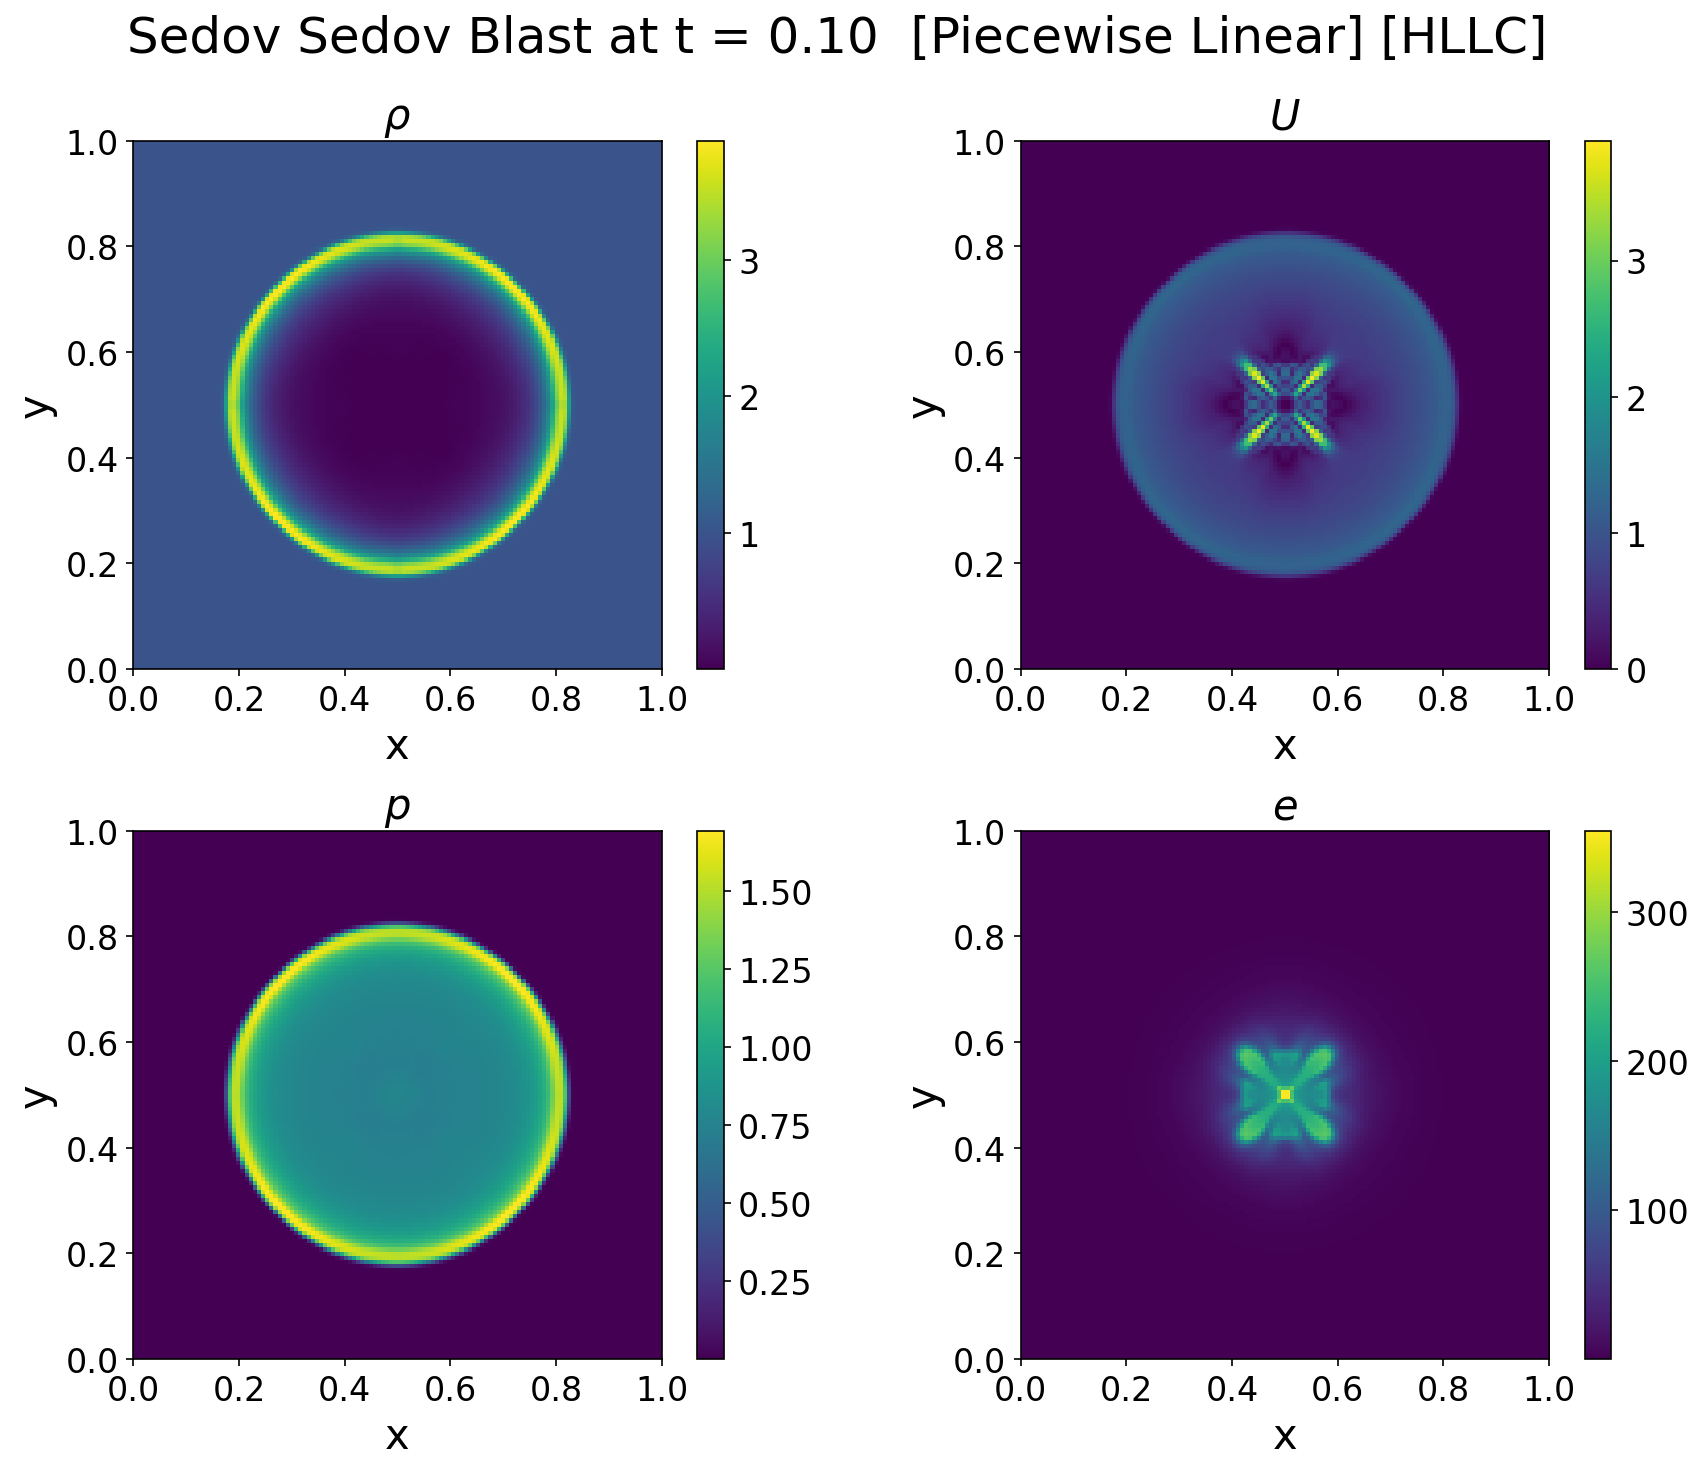

In [ ]:
# Sod problem setting up variables and visualizing

DOFs_Sedov = 4
nx = 128
ny = 128
dx = 1/nx
dy = 1/ny
C = 0.8
gamma = 1.4
tf = 0.1

X = np.linspace(0,1,nx)
Y = np.linspace(0,1,ny)

#need vector valued solution vector U = (rho, rho u, rho v, rho E)
U_ghost_IC_Sedov = np.zeros((DOFs_Sedov, ny + 2*nghost, nx + 2*nghost))
U_sedov_blast = sedov_blast(U_ghost_IC_Sedov, gamma, nx, ny)
U_ghost_IC_Sedov[:, nghost:nghost+ny, nghost:nghost+nx] = U_sedov_blast[:, nghost:nghost+ny, nghost:nghost+nx] # ghosted vector able to have BCs


# U_Sol_Sedov_g1_HLL, all_solns_Sod_g1_HLL, all_t_Sod_g1_HLL = evolve(U_ghost_IC_Sedov, nx, ny, C, tf, gamma, Riemann_HLL, Godunov_type=1)
U_Sol_Sedov_g1_HLLC, all_solns_Sod_g1_HLLC, all_t_Sod_g1_HLLC = evolve(U_ghost_IC_Sedov, nx, ny, C, tf, gamma, Riemann_HLLC, Godunov_type=1)


# plot_solution(X, Y, U_Sol_Sedov_g1_HLL, tf, gamma, 'Sedov', 'Piecewise Linear', 'HLL')
plot_solution(X, Y, U_Sol_Sedov_g1_HLLC, tf, gamma, 'Sedov', 'Piecewise Linear', 'HLLC')


# takes 30 mins for HLLC to run with 128^2, tf = 0.1, C = 0.8, r=0.01
# but i believe it works, or is at least close.

# $\Downarrow$ Make a Movie $\Downarrow$


In [ ]:
#movie_maker(X, Y, all_solns_Sod_g1_HLLC, all_t_Sod_g1_HLLC, gamma, case='Sedov', Riemann='HLLC')

Saved Sedov_HLLC.gif
